# Notebook 01 — Dataset Audit & Reproducibility

## Patient Similarity Network + Agent-Based Modelling for Readmission

### Project structure



Recommended structure:

```text
sna/
│
├── diabetes+130-us+hospitals+for+years+1999-2008/
│   ├── diabetic_data.csv
│   └── IDS_mapping.csv
│
├── notebooks/
│   └── 01_dataset_audit.ipynb
│
├── results/
│
└── figures/
```

The notebook is stored in `notebooks/`.

The raw dataset remains untouched in the separate dataset folder.

Results generated by this notebook are saved in `results/`.

### Purpose

Audit the raw Diabetes 130-US Hospitals dataset before performing any
cleaning, patient-level aggregation, feature engineering, similarity
calculation, network construction, or modelling.

### Notebook objectives

1. Load the raw dataset reproducibly.
2. Verify dataset dimensions and structure.
3. Identify patient and encounter identifiers.
4. Examine data types.
5. Audit NaN and `?` missing values.
6. Check duplicate records and encounter IDs.
7. Inspect the raw `readmitted` target.
8. Inspect important categorical variables.
9. Save audit outputs.


## Before running

Make sure your folders look like:

```text
sna/
├── diabetes+130-us+hospitals+for+years+1999-2008/
│   ├── diabetic_data.csv
│   └── IDS_mapping.csv
├── notebooks/
│   └── 01_dataset_audit.ipynb
├── results/
└── figures/
```

The code below assumes this notebook is located inside `sna/notebooks/`.


In [1]:
# ============================================================
# Cell 1 — Import libraries
# ============================================================

import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version :", platform.python_version())
print("Pandas version :", pd.__version__)
print("NumPy version  :", np.__version__)


Python version : 3.11.9
Pandas version : 3.0.0
NumPy version  : 2.4.1


In [2]:
# ============================================================
# Cell 2 — Define project paths
# ============================================================

# The notebook is inside: sna/notebooks/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Separate dataset folder
DATASET_DIR = PROJECT_ROOT / "diabetes+130-us+hospitals+for+years+1999-2008"

# Separate output folders
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Create output folders if needed
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory :", NOTEBOOK_DIR)
print("Project root       :", PROJECT_ROOT)
print("Dataset directory  :", DATASET_DIR)
print("Results directory  :", RESULTS_DIR)
print("Figures directory  :", FIGURES_DIR)


Notebook directory : c:\Users\Gayatri\OneDrive\Desktop\sna\notebooks
Project root       : c:\Users\Gayatri\OneDrive\Desktop\sna
Dataset directory  : c:\Users\Gayatri\OneDrive\Desktop\sna\diabetes+130-us+hospitals+for+years+1999-2008
Results directory  : c:\Users\Gayatri\OneDrive\Desktop\sna\results
Figures directory  : c:\Users\Gayatri\OneDrive\Desktop\sna\figures


In [3]:
# ============================================================
# Cell 3 — Verify project structure
# ============================================================

print("Project folders/files:\n")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root does not exist: {PROJECT_ROOT}"
    )

for item in sorted(PROJECT_ROOT.iterdir()):
    print("-", item.name)

print("\nDataset folder exists:", DATASET_DIR.exists())
print("Results folder exists:", RESULTS_DIR.exists())
print("Figures folder exists:", FIGURES_DIR.exists())


Project folders/files:

- diabetes+130-us+hospitals+for+years+1999-2008
- figures
- notebooks
- results

Dataset folder exists: True
Results folder exists: True
Figures folder exists: True


In [4]:
# ============================================================
# Cell 4 — Locate the main clinical dataset
# ============================================================

possible_names = [
    "diabetic_data.csv",
    "diabetic_data.CSV",
    "diabetic_data"
]

DATA_FILE = None

if DATASET_DIR.exists():
    for name in possible_names:
        candidate = DATASET_DIR / name
        if candidate.exists():
            DATA_FILE = candidate
            break

    # Case-insensitive fallback
    if DATA_FILE is None:
        for candidate in DATASET_DIR.iterdir():
            if (
                candidate.is_file()
                and candidate.stem.lower() == "diabetic_data"
            ):
                DATA_FILE = candidate
                break

if DATA_FILE is None:
    raise FileNotFoundError(
        "\nCould not find diabetic_data.csv.\n"
        f"Expected location:\n{DATASET_DIR / 'diabetic_data.csv'}\n\n"
        "Check that the dataset folder name and file name are correct."
    )

print("Main clinical dataset found:")
print(DATA_FILE)
print(f"File size: {DATA_FILE.stat().st_size / (1024**2):.2f} MB")


Main clinical dataset found:
c:\Users\Gayatri\OneDrive\Desktop\sna\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv
File size: 18.27 MB


In [5]:
# ============================================================
# Cell 5 — Inspect dataset folder
# ============================================================

print("Files inside the dataset folder:\n")

for item in sorted(DATASET_DIR.iterdir()):
    size_mb = item.stat().st_size / (1024**2) if item.is_file() else 0
    print(f"{item.name:<50} {size_mb:>10.2f} MB")


Files inside the dataset folder:

diabetic_data.csv                                       18.27 MB
IDS_mapping.csv                                          0.00 MB


In [6]:
# ============================================================
# Cell 6 — Load raw dataset
# ============================================================

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (101766, 50)


In [7]:
# ============================================================
# Cell 7 — First five rows
# ============================================================

df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# ============================================================
# Cell 8 — Last five rows
# ============================================================

df.tail()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [9]:
# ============================================================
# Cell 9 — Dataset dimensions
# ============================================================

raw_row_count, raw_column_count = df.shape

print("Raw row count    :", raw_row_count)
print("Raw column count :", raw_column_count)


Raw row count    : 101766
Raw column count : 50


In [10]:
# ============================================================
# Cell 10 — Column names
# ============================================================

print("Column names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")


Column names:

01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


In [11]:
# ============================================================
# Cell 11 — Required project fields
# ============================================================

required_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    print("FAIL — Missing required columns:", missing_required)
else:
    print("PASS — All required columns are present.")


PASS — All required columns are present.


In [12]:
# ============================================================
# Cell 12 — Data types
# ============================================================

dtype_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})

dtype_table


,column,dtype
0,encounter_id,int64
1,patient_nbr,int64
2,race,str
3,gender,str
4,age,str
5,weight,str
6,admission_type_id,int64
7,discharge_disposition_id,int64
8,admission_source_id,int64
9,time_in_hospital,int64


In [13]:
# ============================================================
# Cell 13 — DataFrame information
# ============================================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [14]:
# ============================================================
# Cell 14 — Unique patient count
# ============================================================

unique_patients = df["patient_nbr"].nunique()

print("Unique patients:", unique_patients)
print("Total encounters:", len(df))
print(
    "Average encounters per patient:",
    round(len(df) / unique_patients, 2)
)


Unique patients: 71518
Total encounters: 101766
Average encounters per patient: 1.42


In [15]:
# ============================================================
# Cell 15 — Repeated patients
# ============================================================

patient_id_counts = df["patient_nbr"].value_counts()

patients_once = (patient_id_counts == 1).sum()
patients_multiple = (patient_id_counts > 1).sum()

print("Patients appearing once:", patients_once)
print("Patients appearing more than once:", patients_multiple)
print("Maximum encounters for one patient:", patient_id_counts.max())


Patients appearing once: 54745
Patients appearing more than once: 16773
Maximum encounters for one patient: 40


In [16]:
# ============================================================
# Cell 16 — Encounter ID uniqueness
# ============================================================

unique_encounters = df["encounter_id"].nunique()
duplicate_encounter_ids = df["encounter_id"].duplicated().sum()

print("Total rows:", len(df))
print("Unique encounter IDs:", unique_encounters)
print("Duplicate encounter IDs:", duplicate_encounter_ids)

if unique_encounters == len(df):
    print("PASS — encounter_id is unique.")
else:
    print("FAIL — duplicate encounter_id values detected.")


Total rows: 101766
Unique encounter IDs: 101766
Duplicate encounter IDs: 0
PASS — encounter_id is unique.


In [17]:
# ============================================================
# Cell 17 — NaN missing values
# ============================================================

missing_report = pd.DataFrame({
    "NaN_count": df.isna().sum(),
    "NaN_percentage": (df.isna().mean() * 100).round(2)
}).sort_values("NaN_count", ascending=False)

missing_report.head(20)


,NaN_count,NaN_percentage
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
race,0,0.00
gender,0,0.00
age,0,0.00
weight,0,0.00
admission_type_id,0,0.00
discharge_disposition_id,0,0.00
admission_source_id,0,0.00
time_in_hospital,0,0.00


In [18]:
# ============================================================
# Cell 18 — '?' missing-value code
# ============================================================

question_mark_report = pd.DataFrame({
    "question_mark_count": (df == "?").sum(),
    "question_mark_percentage": ((df == "?").mean() * 100).round(2)
}).sort_values("question_mark_count", ascending=False)

question_mark_report.head(20)


,question_mark_count,question_mark_percentage
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
admission_type_id,0,0.00
patient_nbr,0,0.00
encounter_id,0,0.00


In [19]:
# ============================================================
# Cell 19 — Combined missingness report
# ============================================================

combined_missing_report = pd.DataFrame({
    "NaN_count": df.isna().sum(),
    "NaN_percentage": (df.isna().mean() * 100).round(2),
    "question_mark_count": (df == "?").sum(),
    "question_mark_percentage": ((df == "?").mean() * 100).round(2)
}).sort_values(
    ["NaN_count", "question_mark_count"],
    ascending=False
)

combined_missing_report.head(30)


,NaN_count,NaN_percentage,question_mark_count,question_mark_percentage
max_glu_serum,96420,94.75,0,0.00
A1Cresult,84748,83.28,0,0.00
weight,0,0.00,98569,96.86
medical_specialty,0,0.00,49949,49.08
payer_code,0,0.00,40256,39.56
race,0,0.00,2273,2.23
diag_3,0,0.00,1423,1.40
diag_2,0,0.00,358,0.35
diag_1,0,0.00,21,0.02
encounter_id,0,0.00,0,0.00


In [20]:
# ============================================================
# Cell 20 — Exact duplicate rows
# ============================================================

duplicate_rows = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

if duplicate_rows == 0:
    print("PASS — No exact duplicate rows.")
else:
    print("WARNING — Exact duplicate rows detected.")


Exact duplicate rows: 0
PASS — No exact duplicate rows.


In [21]:
# ============================================================
# Cell 21 — Raw readmission target distribution
# ============================================================

target_counts = df["readmitted"].value_counts(dropna=False)
target_percentages = (
    df["readmitted"]
    .value_counts(dropna=False, normalize=True)
    * 100
)

target_report = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_report


,count,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


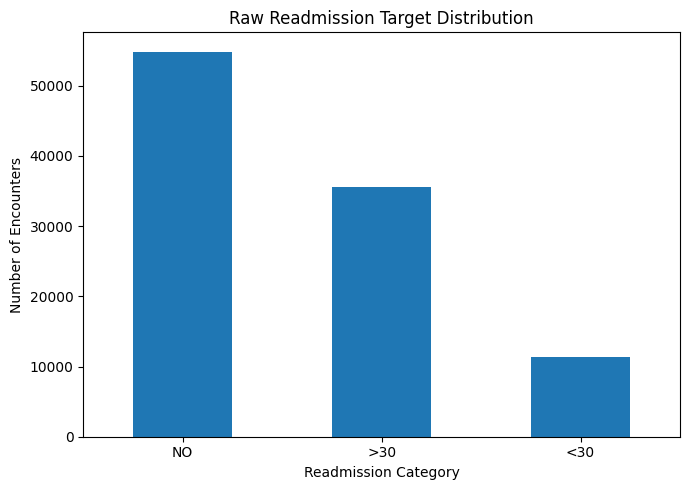

In [22]:
# ============================================================
# Cell 22 — Plot raw target distribution
# ============================================================

plt.figure(figsize=(7, 5))

df["readmitted"].value_counts().plot(kind="bar")

plt.title("Raw Readmission Target Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_raw_readmission_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [23]:
# ============================================================
# Cell 23 — Categorical columns
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of categorical columns:", len(categorical_columns))

for col in categorical_columns:
    print("-", col)


Number of categorical columns: 37
- race
- gender
- age
- weight
- payer_code
- medical_specialty
- diag_1
- diag_2
- diag_3
- max_glu_serum
- A1Cresult
- metformin
- repaglinide
- nateglinide
- chlorpropamide
- glimepiride
- acetohexamide
- glipizide
- glyburide
- tolbutamide
- pioglitazone
- rosiglitazone
- acarbose
- miglitol
- troglitazone
- tolazamide
- examide
- citoglipton
- insulin
- glyburide-metformin
- glipizide-metformin
- glimepiride-pioglitazone
- metformin-rosiglitazone
- metformin-pioglitazone
- change
- diabetesMed
- readmitted


C:\Users\Gayatri\AppData\Local\Temp\ipykernel_16972\1005048749.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [24]:
# ============================================================
# Cell 24 — Number of unique values
# ============================================================

unique_value_report = pd.DataFrame({
    "column": df.columns,
    "n_unique": [
        df[col].nunique(dropna=False)
        for col in df.columns
    ],
    "dtype": df.dtypes.astype(str).values
})

unique_value_report.sort_values(
    "n_unique",
    ascending=True
).head(30)


,column,n_unique,dtype
40,citoglipton,1,str
39,examide,1,str
29,acetohexamide,2,str
43,glipizide-metformin,2,str
32,tolbutamide,2,str
37,troglitazone,2,str
45,metformin-rosiglitazone,2,str
44,glimepiride-pioglitazone,2,str
46,metformin-pioglitazone,2,str
47,change,2,str


In [25]:
# ============================================================
# Cell 25 — Important categorical variables
# ============================================================

important_categorical = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "medical_specialty",
    "payer_code",
    "change",
    "diabetesMed",
    "readmitted"
]

for col in important_categorical:
    if col in df.columns:
        print("\n" + "=" * 60)
        print(col)
        print("=" * 60)
        print(df[col].value_counts(dropna=False).head(20))



race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

admission_type_id
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

discharge_disposition_id
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
Name: count, dtype: int64

admission_sou

In [26]:
# ============================================================
# Cell 26 — Identifier candidates
# ============================================================

identifier_candidates = []

for col in df.columns:
    if df[col].nunique(dropna=False) == len(df):
        identifier_candidates.append(col)

print("Columns with one unique value per row:")

for col in identifier_candidates:
    print("-", col)


Columns with one unique value per row:
- encounter_id


In [27]:
# ============================================================
# Cell 27 — Encounters per patient distribution
# ============================================================

patient_id_counts.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          3.000000
99%          6.000000
max         40.000000
Name: count, dtype: float64

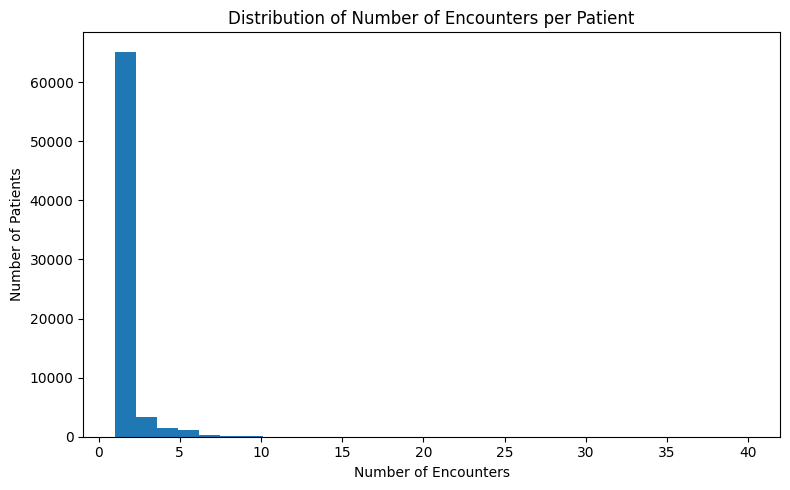

In [28]:
# ============================================================
# Cell 28 — Plot encounters per patient
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(patient_id_counts, bins=30)

plt.title("Distribution of Number of Encounters per Patient")
plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_encounters_per_patient.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [29]:
# ============================================================
# Cell 29 — General dataset summary
# ============================================================

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [30]:
# ============================================================
# Cell 30 — Memory usage
# ============================================================

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Dataset memory usage: {memory_mb:.2f} MB")


Dataset memory usage: 48.60 MB


In [31]:
# ============================================================
# Cell 31 — Create column dictionary
# ============================================================

column_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_unique": [
        df[col].nunique(dropna=False)
        for col in df.columns
    ],
    "missing_nan": [
        df[col].isna().sum()
        for col in df.columns
    ],
    "missing_question_mark": [
        (df[col] == "?").sum()
        for col in df.columns
    ]
})

column_dictionary


,column,dtype,n_unique,missing_nan,missing_question_mark
0,encounter_id,int64,101766,0,0
1,patient_nbr,int64,71518,0,0
2,race,str,6,0,2273
3,gender,str,3,0,0
4,age,str,10,0,0
5,weight,str,10,0,98569
6,admission_type_id,int64,8,0,0
7,discharge_disposition_id,int64,26,0,0
8,admission_source_id,int64,17,0,0
9,time_in_hospital,int64,14,0,0


In [32]:
# ============================================================
# Cell 32 — Save column dictionary
# ============================================================

column_dictionary.to_csv(
    RESULTS_DIR / "01_column_dictionary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "01_column_dictionary.csv")


Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\results\01_column_dictionary.csv


In [33]:
# ============================================================
# Cell 33 — Save missingness report
# ============================================================

combined_missing_report.to_csv(
    RESULTS_DIR / "01_missingness_report.csv"
)

print("Saved:", RESULTS_DIR / "01_missingness_report.csv")


Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\results\01_missingness_report.csv


In [34]:
# ============================================================
# Cell 34 — Save target distribution
# ============================================================

target_report.to_csv(
    RESULTS_DIR / "01_target_distribution.csv"
)

print("Saved:", RESULTS_DIR / "01_target_distribution.csv")


Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\results\01_target_distribution.csv


In [35]:
# ============================================================
# Cell 35 — Create audit summary
# ============================================================

audit_summary = {
    "dataset_file": DATA_FILE.name,
    "dataset_path": str(DATA_FILE),
    "raw_rows": int(len(df)),
    "raw_columns": int(len(df.columns)),
    "unique_patients": int(df["patient_nbr"].nunique()),
    "unique_encounters": int(df["encounter_id"].nunique()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "duplicate_encounter_ids": int(
        df["encounter_id"].duplicated().sum()
    ),
    "categorical_columns": int(len(categorical_columns)),
    "total_nan_cells": int(df.isna().sum().sum()),
    "total_question_mark_cells": int((df == "?").sum().sum()),
    "target_column": "readmitted",
    "target_categories": [
        str(x) for x in df["readmitted"].dropna().unique()
    ]
}

print(json.dumps(audit_summary, indent=4))


{
    "dataset_file": "diabetic_data.csv",
    "dataset_path": "c:\\Users\\Gayatri\\OneDrive\\Desktop\\sna\\diabetes+130-us+hospitals+for+years+1999-2008\\diabetic_data.csv",
    "raw_rows": 101766,
    "raw_columns": 50,
    "unique_patients": 71518,
    "unique_encounters": 101766,
    "exact_duplicate_rows": 0,
    "duplicate_encounter_ids": 0,
    "categorical_columns": 37,
    "total_nan_cells": 181168,
    "total_question_mark_cells": 192849,
    "target_column": "readmitted",
    "target_categories": [
        "NO",
        ">30",
        "<30"
    ]
}


In [36]:
# ============================================================
# Cell 36 — Save audit summary
# ============================================================

with open(
    RESULTS_DIR / "01_dataset_audit_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(audit_summary, f, indent=4)

print("Saved:", RESULTS_DIR / "01_dataset_audit_summary.json")


Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\results\01_dataset_audit_summary.json


In [37]:
# ============================================================
# Cell 37 — Save reproducibility configuration
# ============================================================

config = {
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "dataset_file": DATA_FILE.name,
    "dataset_path": str(DATA_FILE),
    "raw_rows": int(len(df)),
    "raw_columns": int(len(df.columns)),
    "unique_patients": int(df["patient_nbr"].nunique()),
    "unique_encounters": int(df["encounter_id"].nunique())
}

with open(
    RESULTS_DIR / "01_reproducibility_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(config, f, indent=4)

print(json.dumps(config, indent=4))


{
    "python_version": "3.11.9",
    "pandas_version": "3.0.0",
    "numpy_version": "2.4.1",
    "dataset_file": "diabetic_data.csv",
    "dataset_path": "c:\\Users\\Gayatri\\OneDrive\\Desktop\\sna\\diabetes+130-us+hospitals+for+years+1999-2008\\diabetic_data.csv",
    "raw_rows": 101766,
    "raw_columns": 50,
    "unique_patients": 71518,
    "unique_encounters": 101766
}


In [38]:
# ============================================================
# Cell 38 — FINAL AUTOMATED CHECKPOINT
# ============================================================

print("=" * 75)
print("NOTEBOOK 01 — FINAL CHECKPOINT")
print("=" * 75)

checks = {}

checks["dataset_loaded"] = len(df) > 0

checks["required_columns_present"] = all(
    col in df.columns
    for col in ["encounter_id", "patient_nbr", "readmitted"]
)

checks["patient_id_available"] = (
    df["patient_nbr"].notna().all()
)

checks["encounter_id_unique"] = (
    df["encounter_id"].nunique() == len(df)
)

checks["multiple_patients"] = (
    df["patient_nbr"].nunique() > 1
)

checks["target_available"] = (
    df["readmitted"].notna().any()
)

checks["reasonable_column_count"] = (
    len(df.columns) > 10
)

for name, result in checks.items():
    print(f"{'PASS' if result else 'FAIL':<6} | {name}")

print("=" * 75)

if all(checks.values()):
    print("OVERALL RESULT: PASS")
    print("Proceed to MANUAL REVIEW.")
else:
    print("OVERALL RESULT: FAIL")
    print("Fix the failed checks before moving to Notebook 02.")


NOTEBOOK 01 — FINAL CHECKPOINT
PASS   | dataset_loaded
PASS   | required_columns_present
PASS   | patient_id_available
PASS   | encounter_id_unique
PASS   | multiple_patients
PASS   | target_available
PASS   | reasonable_column_count
OVERALL RESULT: PASS
Proceed to MANUAL REVIEW.
